In [12]:
import lbforaging
import numpy as np
import matplotlib.pyplot as plt

from games.mp import MP
from games.rps import RPS
from games.bos import BoS
from games.foraging import Foraging
from agents.jal_am import JointActionLearningAM

## Matrix Games

### Matching Pennies (MP)

Zero-sum game. Nash equilibrium: both agents play [0.5, 0.5].

In [13]:
g = MP()
g.reset()
print(f"agent_0 reward matrix:\n{g._R}")
print(f"agent_1 reward matrix:\n{-g._R}")

agent_0 reward matrix:
[[ 1. -1.]
 [-1.  1.]]
agent_1 reward matrix:
[[-1.  1.]
 [ 1. -1.]]


In [14]:
jal_mp = {agent: JointActionLearningAM(game=g, agent=agent, seed=42) for agent in g.agents}

for i in range(10000):
    actions = {agent: jal_mp[agent].action() for agent in g.agents}
    g.step(actions)

In [15]:
{agent: jal_mp[agent].policy() for agent in g.agents}

{'agent_0': array([0.36788794, 0.63211206]),
 'agent_1': array([0.39155384, 0.60844616])}

### Rock-Paper-Scissors (RPS)

Cyclic zero-sum game. Nash equilibrium: both agents play [1/3, 1/3, 1/3].

In [16]:
g = RPS()
g.reset()
print(f"agent_0 reward matrix:\n{g._R}")
print(f"agent_1 reward matrix:\n{-g._R}")

agent_0 reward matrix:
[[ 0. -1.  1.]
 [ 1.  0. -1.]
 [-1.  1.  0.]]
agent_1 reward matrix:
[[-0.  1. -1.]
 [-1. -0.  1.]
 [ 1. -1. -0.]]


In [17]:
jal_rps = {agent: JointActionLearningAM(game=g, agent=agent, seed=42) for agent in g.agents}

for i in range(10000):
    actions = {agent: jal_rps[agent].action() for agent in g.agents}
    g.step(actions)

In [18]:
{agent: jal_rps[agent].policy() for agent in g.agents}

{'agent_0': array([0.33333333, 0.33333333, 0.33333333]),
 'agent_1': array([0.33333333, 0.33333333, 0.33333333])}

### Battle of Sexes (BoS)

Coordination game with two pure Nash equilibria: (Cine, Cine) and (Partido, Partido).

In [19]:
g = BoS()
g.reset()
for agent in g.agents:
    print(f"{agent} reward matrix:\n{g._R[agent]}")

agent_0 reward matrix:
[[2. 0.]
 [0. 1.]]
agent_1 reward matrix:
[[1. 0.]
 [0. 2.]]


In [20]:
jal_bos = {agent: JointActionLearningAM(game=g, agent=agent, seed=42) for agent in g.agents}

for i in range(10000):
    actions = {agent: jal_bos[agent].action() for agent in g.agents}
    g.step(actions)

In [21]:
{agent: jal_bos[agent].policy() for agent in g.agents}

{'agent_0': array([3.67893354e-06, 9.99996321e-01]),
 'agent_1': array([2.18325158e-06, 9.99997817e-01])}

## Foraging (Episodic)

In [22]:
def epsilon_decay(max_t, min_eps=0.01):
    """Compute per-step decay so epsilon reaches min_eps after max_t steps."""
    return min_eps ** (1 / max_t)

game_config = [
    "Foraging-5x5-2p-1f-v3",
    "Foraging-8x8-2p-1f-v3",
    "Foraging-8x8-3p-1f-v3",
    "Foraging-8x8-3p-1f-coop-v3",
]

configurations = {
    '0': {
        'game': game_config[0],
        'jal_am': {'alpha': 0.1, 'epsilon_min': 0.01, 'epsilon_decay': epsilon_decay(25_000), 'seed': 1},
        'train_config': {'episodes': 100, 'iterations': 10},
    },
    '1': {
        'game': game_config[1],
        'jal_am': {'alpha': 0.1, 'epsilon_min': 0.01, 'epsilon_decay': epsilon_decay(250_000), 'seed': 1},
        'train_config': {'episodes': 100, 'iterations': 50},
    },
    '2': {
        'game': game_config[2],
        'jal_am': {'alpha': 0.1, 'epsilon_min': 0.01, 'epsilon_decay': epsilon_decay(500_000), 'seed': 1},
        'train_config': {'episodes': 100, 'iterations': 100},
    },
    '3': {
        'game': game_config[3],
        'jal_am': {'alpha': 0.1, 'epsilon_min': 0.01, 'epsilon_decay': epsilon_decay(1_500_000), 'seed': 1},
        'train_config': {'episodes': 1000, 'iterations': 100},
    },
}

In [23]:
config = configurations['0']
game = Foraging(config=config['game'], seed=1)
agents = {agent: JointActionLearningAM(game=game, agent=agent, **config['jal_am']) for agent in game.agents}

In [24]:
game.reset()
for agent in game.agents:
    print(f"Agent: {agent}")
    print(f"Observation: {game.observe(agent)}")

Agent: agent_0
Observation: [3. 1. 2. 2. 3. 2. 0. 0. 2.]
Agent: agent_1
Observation: [3. 1. 2. 0. 0. 2. 2. 3. 2.]


In [25]:
def play_episode(game, agents, verbose=False, render=False):
    import time

    game.reset()
    step_count = 0

    # JAL-AM has no reset() method; reset episode-tracking state manually
    for agent in game.agents:
        agents[agent]._s = None
        agents[agent]._prev_action = None

    if verbose:
        print(f"Step: {step_count}")
        for agent in game.agents:
            print(f"Agent {agent} observe: {game.observe(agent)}")

    cum_rewards = {agent: 0.0 for agent in game.agents}

    if render:
        game.render()
        time.sleep(0.5)

    while not game.done():
        step_count += 1

        actions = {agent: agents[agent].action() for agent in game.agents}
        game.step(actions)

        for agent in game.agents:
            cum_rewards[agent] += game.reward(agent)

        if verbose:
            print(f"Step: {step_count}")
            for agent in game.agents:
                print(f"Agent {agent} action: {actions[agent]} - {game.action_set[actions[agent]]}")
                print(f"Agent {agent} reward: {game.reward(agent)}")
                print(f"Agent {agent} observe: {game.observe(agent)}")

        if render:
            game.render()
            time.sleep(0.5)

    # Process terminal reward (last transition not yet seen by action())
    for agent in game.agents:
        agents[agent].update()

    return cum_rewards

In [26]:
def run(game, agents, episodes=1, verbose=False, render=False):
    sum_rewards = {agent: 0.0 for agent in game.agents}
    for _ in range(episodes):
        cum_rewards = play_episode(game, agents, verbose=verbose, render=render)
        for agent in game.agents:
            sum_rewards[agent] += cum_rewards[agent]
    if verbose:
        print(f"Average rewards over {episodes} episodes:")
        for agent in game.agents:
            print(f"Agent {agent}: {sum_rewards[agent] / episodes}")
    return sum_rewards

In [27]:
def train(game, agents, train_config, progress=False, verbose=False, render=False):
    iterations = train_config["iterations"]
    episodes = train_config["episodes"]
    average_rewards = {agent: [] for agent in game.agents}
    for i in range(1, iterations + 1):
        sum_rewards = run(game, agents, episodes=episodes, verbose=False, render=False)
        for agent in game.agents:
            average_rewards[agent].append(sum_rewards[agent] / episodes)
        if progress and (i % 10 == 0):
            print(f"Iteration {i} ({i * episodes} episodes)")
            for agent in game.agents:
                print(f"Agent {agent}: {average_rewards[agent][-1]}")
    if progress:
        print(f"Last average rewards over {iterations} iterations ({iterations * episodes} episodes):")
        for agent in game.agents:
            print(f"Agent {agent}: {average_rewards[agent][-1]}")
    return average_rewards

In [28]:
average_rewards = train(game, agents, train_config=config['train_config'], progress=True)

/Users/nataliacampigliastemphelet/master/simultaneous-games/.venv/lib/python3.11/site-packages/gymnasium/utils/passive_env_checker.py:245: UserWarning: WARN: The reward returned by `step()` must be a float, int, np.integer or np.floating, actual type: <class 'list'>
  logger.warn(


Iteration 10 (1000 episodes)
Agent agent_0: 0.7916666666666667
Agent agent_1: 0.19833333333333336
Last average rewards over 10 iterations (1000 episodes):
Agent agent_0: 0.7916666666666667
Agent agent_1: 0.19833333333333336


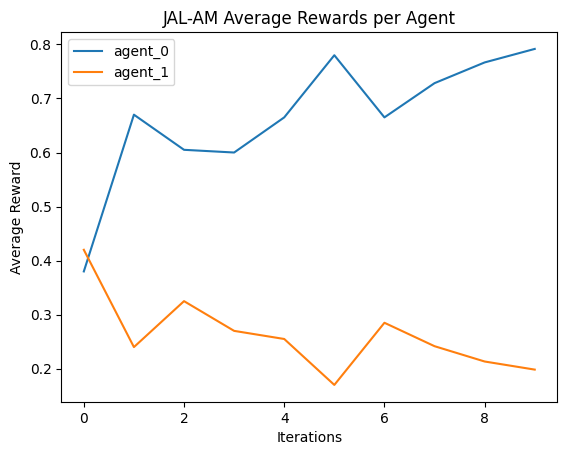

In [29]:
for agent, rewards in average_rewards.items():
    plt.plot(rewards, label=agent)

plt.xlabel('Iterations')
plt.ylabel('Average Reward')
plt.title('JAL-AM Average Rewards per Agent')
plt.legend()
plt.show()

In [30]:
for agent in game.agents:
    agents[agent].epsilon = 0.0
    agents[agent].alpha = 0.0

In [31]:
play_episode(game, agents, verbose=True, render=False)

Step: 0
Agent agent_0 observe: [3. 1. 2. 2. 3. 2. 0. 0. 2.]
Agent agent_1 observe: [3. 1. 2. 0. 0. 2. 2. 3. 2.]
Step: 1
Agent agent_0 action: 3 - WEST
Agent agent_0 reward: 0
Agent agent_0 observe: [3. 1. 2. 2. 2. 2. 1. 0. 2.]
Agent agent_1 action: 2 - SOUTH
Agent agent_1 reward: 0
Agent agent_1 observe: [3. 1. 2. 1. 0. 2. 2. 2. 2.]
Step: 2
Agent agent_0 action: 3 - WEST
Agent agent_0 reward: 0
Agent agent_0 observe: [3. 1. 2. 2. 1. 2. 2. 0. 2.]
Agent agent_1 action: 2 - SOUTH
Agent agent_1 reward: 0
Agent agent_1 observe: [3. 1. 2. 2. 0. 2. 2. 1. 2.]
Step: 3
Agent agent_0 action: 5 - LOAD
Agent agent_0 reward: 1.0
Agent agent_0 observe: [-1. -1.  0.  2.  1.  2.  2.  0.  2.]
Agent agent_1 action: 4 - EAST
Agent agent_1 reward: 0
Agent agent_1 observe: [-1. -1.  0.  2.  0.  2.  2.  1.  2.]


{'agent_0': 1.0, 'agent_1': 0.0}